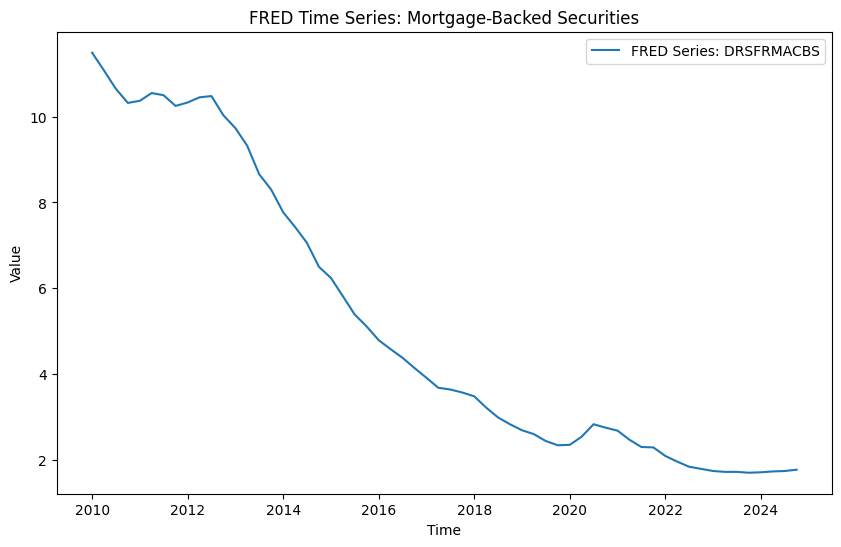

In [ ]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader.data as web

# Set the date range
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime.today()

# Fetch data from FRED: Assets: Other: Securities: Mortgage-backed Securities
df = web.DataReader("DRSFRMACBS", "fred", start, end)

# Drop any missing values
df = df.dropna().reset_index()
df.columns = ["time", "value"]

# Convert datetime to ordinal for modeling
df["time"] = pd.to_datetime(df["time"])

# Visualize the FRED time series
plt.figure(figsize=(10, 6))
plt.plot(df["time"], df["value"], label="FRED Series: DRSFRMACBS")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("FRED Time Series: Mortgage-Backed Securities")
plt.legend()

plt.show()

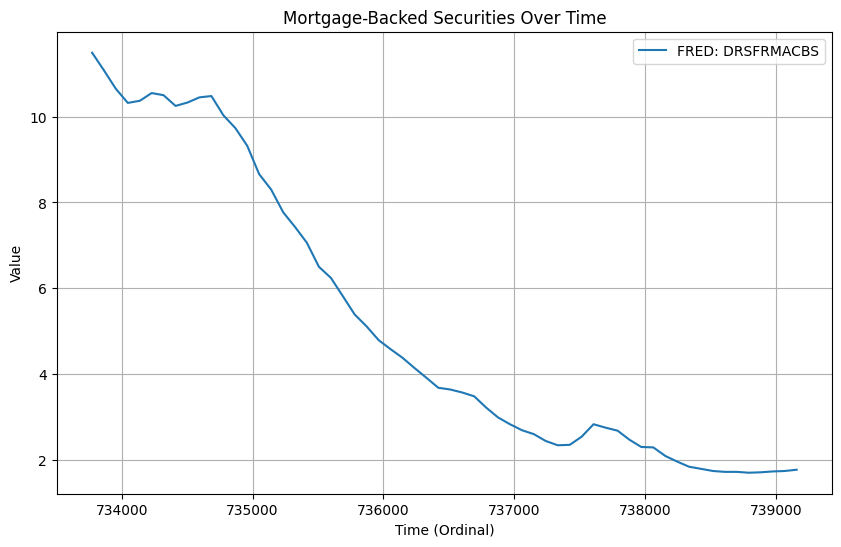

Epoch [10/100], Loss: 0.196935
Epoch [20/100], Loss: 0.130294
Epoch [30/100], Loss: 0.087695
Epoch [40/100], Loss: 0.052740
Epoch [50/100], Loss: 0.027799
Epoch [60/100], Loss: 0.014571
Epoch [70/100], Loss: 0.011255
Epoch [80/100], Loss: 0.011342
Epoch [90/100], Loss: 0.011040
Epoch [100/100], Loss: 0.010575


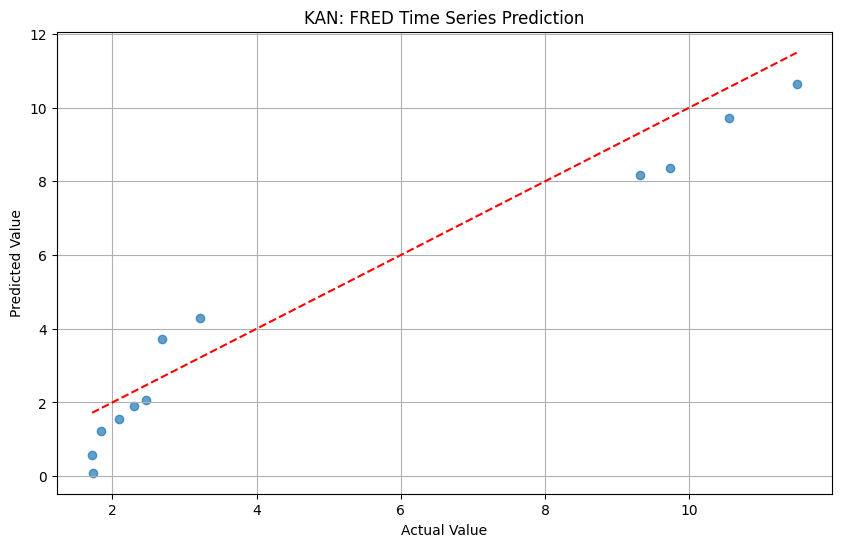

In [ ]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Step 1: Load FRED Data
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime.today()

df = web.DataReader("DRSFRMACBS", "fred", start, end)
df = df.dropna().reset_index()
df.columns = ["time", "value"]
df["time"] = df["time"].map(datetime.datetime.toordinal)

# Visualize the time series
plt.figure(figsize=(10, 6))
plt.plot(df["time"], df["value"], label="FRED: DRSFRMACBS")
plt.xlabel("Time (Ordinal)")
plt.ylabel("Value")
plt.title("Mortgage-Backed Securities Over Time")
plt.legend()
plt.grid()
plt.savefig("fred_kan_series.png")
plt.show()

# Step 2: Prepare Data
X = np.array(df["time"]).reshape(-1, 1)
y = np.array(df["value"]).reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# Step 3: Define the Kolmogorov-Arnold Network
class KolmogorovArnoldNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.decomposition = nn.Linear(input_dim, hidden_dim)
        self.aggregation = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h = torch.tanh(self.decomposition(x))
        g = self.aggregation(h)
        return g


# Step 4: Train the KAN Model
input_dim = 1
hidden_dim = 10
output_dim = 1
learning_rate = 0.01
num_epochs = 100

model = KolmogorovArnoldNetwork(input_dim, hidden_dim, output_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.6f}")

# Step 5: Evaluate the Model
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predictions_np = scaler_y.inverse_transform(predictions.numpy())
    y_test_np = scaler_y.inverse_transform(y_test_tensor.numpy())

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_np, predictions_np, alpha=0.7)
plt.plot(
    [y_test_np.min(), y_test_np.max()],
    [y_test_np.min(), y_test_np.max()],
    color="red",
    linestyle="--",
)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("KAN: FRED Time Series Prediction")
plt.grid()
plt.savefig("kan_fred_predictions.png")
plt.show()

Epoch 10/100, Loss: 0.012741
Epoch 20/100, Loss: 0.001567
Epoch 30/100, Loss: 0.002612
Epoch 40/100, Loss: 0.001506
Epoch 50/100, Loss: 0.001515
Epoch 60/100, Loss: 0.001355
Epoch 70/100, Loss: 0.001280
Epoch 80/100, Loss: 0.001223
Epoch 90/100, Loss: 0.001173
Epoch 100/100, Loss: 0.001130


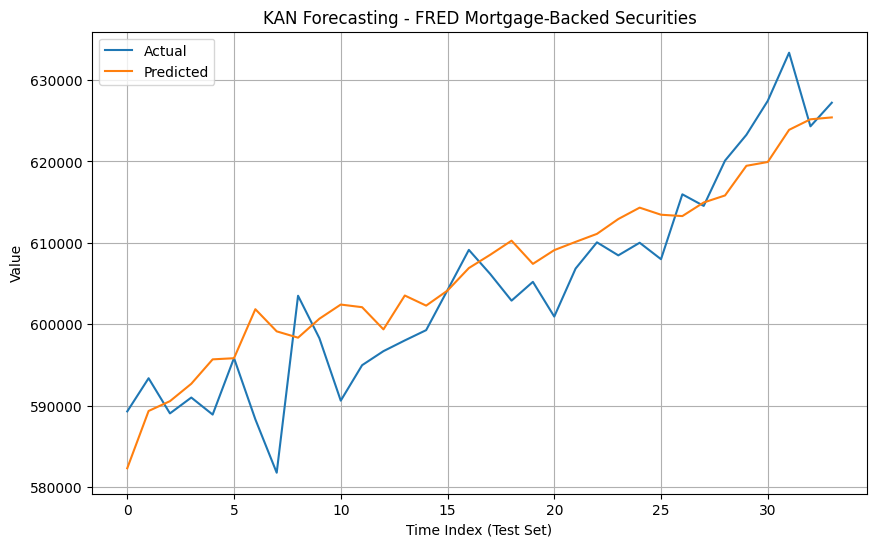

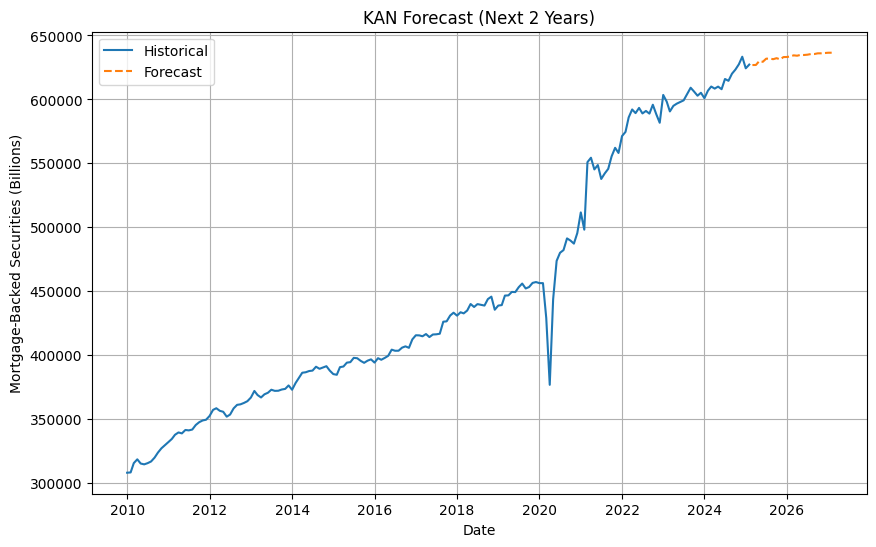

In [ ]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Load FRED data
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime.today()
df = web.DataReader("RSXFS", "fred", start, end).dropna().reset_index()
df.columns = ["date", "value"]

# Normalize values
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[["value"]].values)

# Create sliding window data
window_size = 12  # 12 months = 1 year
X, y = [], []
for i in range(len(scaled_values) - window_size):
    X.append(scaled_values[i : i + window_size].flatten())
    y.append(scaled_values[i + window_size][0])
X, y = np.array(X), np.array(y).reshape(-1, 1)

# Train-test split (chronological)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# Define the KAN model
class KolmogorovArnoldNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.decomposition = nn.Linear(input_dim, hidden_dim)
        self.aggregation = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h = torch.tanh(self.decomposition(x))
        return self.aggregation(h)


# Initialize model
input_dim = window_size
hidden_dim = 10
output_dim = 1
model = KolmogorovArnoldNetwork(input_dim, hidden_dim, output_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train the model
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.6f}")

# Evaluate on test data
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test)

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test_actual)), y_test_actual, label="Actual")
plt.plot(range(len(predictions)), predictions, label="Predicted")
plt.title("KAN Forecasting - FRED Mortgage-Backed Securities")
plt.xlabel("Time Index (Test Set)")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.savefig("kan_forecast_testset.png")
plt.show()

# Recursive multi-step forecasting
steps_ahead = 24  # Forecast next 2 years (monthly)
last_known = scaled_values[-window_size:].flatten()
forecast_scaled = []

with torch.no_grad():
    for _ in range(steps_ahead):
        input_tensor = torch.tensor(last_known.reshape(1, -1), dtype=torch.float32)
        pred = model(input_tensor).item()
        forecast_scaled.append(pred)
        last_known = np.append(last_known[1:], pred)

# Denormalize forecast
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# Plot forecast
forecast_dates = pd.date_range(
    start=df["date"].iloc[-1] + pd.DateOffset(months=1), periods=steps_ahead, freq="MS"
)
plt.figure(figsize=(10, 6))
plt.plot(df["date"], df["value"], label="Historical")
plt.plot(forecast_dates, forecast, label="Forecast", linestyle="--")
plt.title("KAN Forecast (Next 2 Years)")
plt.xlabel("Date")
plt.ylabel("Mortgage-Backed Securities (Billions)")
plt.legend()
plt.grid()
plt.savefig("kan_forecast_future.png")
plt.show()

In [ ]:
# Re-run with updated environment (data already available from previous steps)
import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA

# Load FRED data
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime.today()
df = web.DataReader("RSXFS", "fred", start, end).dropna().reset_index()
df.columns = ["date", "value"]
df["date"] = pd.to_datetime(df["date"])


# Normalize for KAN
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[["value"]].values)

# Create lagged input-output for KAN
window_size = 12
X, y = [], []
for i in range(len(scaled_values) - window_size):
    X.append(scaled_values[i : i + window_size].flatten())
    y.append(scaled_values[i + window_size][0])
X, y = np.array(X), np.array(y).reshape(-1, 1)

# Chronological train-test split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# Define KAN model
class KolmogorovArnoldNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.decomposition = nn.Linear(input_dim, hidden_dim)
        self.aggregation = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h = torch.tanh(self.decomposition(x))
        return self.aggregation(h)


# Train KAN
input_dim = window_size
model = KolmogorovArnoldNetwork(input_dim, 10, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    model.train()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate KAN
model.eval()
with torch.no_grad():
    predictions_kan = model(X_test_tensor).numpy()
    predictions_kan = scaler.inverse_transform(predictions_kan)
    y_test_actual = scaler.inverse_transform(y_test)


# Fit ARIMA on original values
train_arima = df["value"].iloc[: train_size + window_size]
test_arima = df["value"].iloc[train_size + window_size :]

model_arima = ARIMA(train_arima, order=(5, 1, 0)).fit()
predictions_arima = model_arima.forecast(steps=len(test_arima))


import numpy as np
from sklearn.metrics import mean_squared_error

mse_kan = mean_squared_error(y_test_actual, predictions_kan)
rmse_kan = np.sqrt(mse_kan)

mse_arima = mean_squared_error(test_arima.values, predictions_arima.values)
rmse_arima = np.sqrt(mse_arima)


# Create RMSE comparison table
rmse_df = pd.DataFrame({"Model": ["KAN", "ARIMA"], "RMSE": [rmse_kan, rmse_arima]})

In [ ]:
rmse_df

,Model,RMSE
0,KAN,6745.667053
1,ARIMA,18121.760307


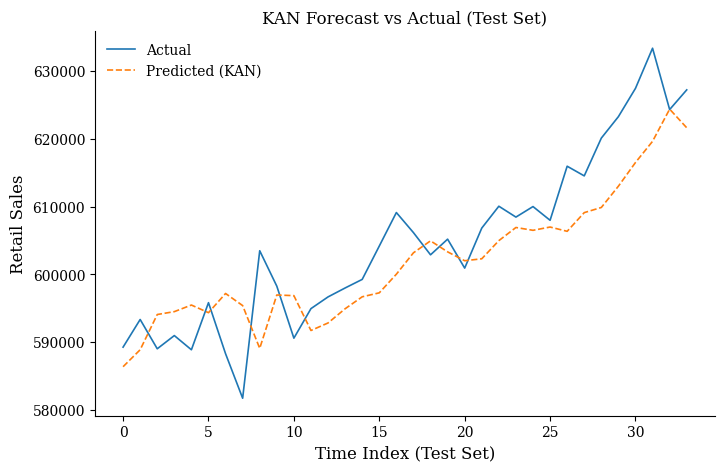

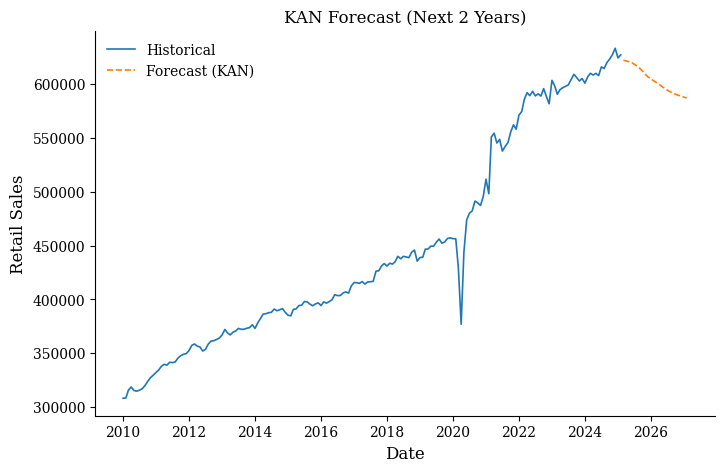

In [ ]:
import matplotlib.pyplot as plt


# Minimalist style configuration (inspired by Edward Tufte)
def minimalist_plot_setup():
    plt.rcParams.update(
        {
            "font.family": "serif",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.spines.left": True,
            "axes.spines.bottom": True,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
        }
    )


# Plot 1: Predicted vs Actual (Test Set)
minimalist_plot_setup()
plt.figure(figsize=(8, 5))
plt.plot(y_test_actual, label="Actual", linewidth=1.2)
plt.plot(predictions_kan, label="Predicted (KAN)", linestyle="--", linewidth=1.2)
plt.xlabel("Time Index (Test Set)")
plt.ylabel("Retail Sales")
plt.title("KAN Forecast vs Actual (Test Set)")
plt.legend(frameon=False)
plt.savefig("kan_vs_actual_testset.png", bbox_inches="tight")
plt.show()

# Plot 2: Recursive Forecast (Next 24 Months)
steps_ahead = 24
last_known_scaled = scaled_values[-window_size:].flatten()
forecast_scaled = []

model.eval()
with torch.no_grad():
    for _ in range(steps_ahead):
        input_tensor = torch.tensor(
            last_known_scaled.reshape(1, -1), dtype=torch.float32
        )
        pred = model(input_tensor).item()
        forecast_scaled.append(pred)
        last_known_scaled = np.append(last_known_scaled[1:], pred)

forecast_unscaled = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# Prepare future dates
last_date = df["date"].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1), periods=steps_ahead, freq="MS"
)

# Plot 2
minimalist_plot_setup()
plt.figure(figsize=(8, 5))
plt.plot(df["date"], df["value"], label="Historical", linewidth=1.2)
plt.plot(
    future_dates,
    forecast_unscaled,
    label="Forecast (KAN)",
    linestyle="--",
    linewidth=1.2,
)
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.title("KAN Forecast (Next 2 Years)")
plt.legend(frameon=False)
plt.savefig("kan_forecast_future.png", bbox_inches="tight")
plt.show()